In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import esmpy

This script creates input file that can be used by CICE to correct sea-ice initial conditions based on the observated values.

1. The `restart_mod` option in `ice_in` needs to be set to `'adjust_aice'`
2. The file `sic.nc` needs to be placed under `RESTART` directory.

In [2]:
grid_path = '/glade/derecho/scratch/turuncu/data/Run_global/postprocessed/grids'

grid_obsN = esmpy.Grid(filename=f'{grid_path}/obsN_grid.nc', filetype=esmpy.constants.FileFormat.SCRIP, is_sphere=True)
grid_obsS = esmpy.Grid(filename=f'{grid_path}/obsS_grid.nc', filetype=esmpy.constants.FileFormat.SCRIP, is_sphere=True)
grid_cice = esmpy.Grid(filename=f'{grid_path}/cice_grid.nc', filetype=esmpy.constants.FileFormat.SCRIP, is_sphere=True)

field_obsN = esmpy.Field(grid_obsN, staggerloc=esmpy.StaggerLoc.CENTER)
field_obsS = esmpy.Field(grid_obsS, staggerloc=esmpy.StaggerLoc.CENTER)
field_cice = esmpy.Field(grid_cice, staggerloc=esmpy.StaggerLoc.CENTER)

regrid_obsN2cice = esmpy.Regrid(
    field_obsN,
    field_cice,
    regrid_method=esmpy.RegridMethod.BILINEAR,
    unmapped_action=esmpy.UnmappedAction.IGNORE
)

regrid_obsS2cice = esmpy.Regrid(
    field_obsS,
    field_cice,
    regrid_method=esmpy.RegridMethod.BILINEAR,
    unmapped_action=esmpy.UnmappedAction.IGNORE
)

In [27]:
data_path = '/glade/derecho/scratch/turuncu/data/Run_global/postprocessed'

ds_obsN = xr.open_dataset(f'{data_path}/OSISAF-GLO-SEAICE_CONC_CONT_TIMESERIES-NH-LA-OBS_multi-vars_180.00W-179.70E_40.00N-90.00N_2021-01-01-2021-12-31.nc')
ds_obsS = xr.open_dataset(f'{data_path}/OSISAF-GLO-SEAICE_CONC_CONT_TIMESERIES-SH-LA-OBS_multi-vars_180.00W-179.70E_90.00S-40.00S_2021-01-01-2021-12-31.nc')
ds_cice = xr.open_dataset(f'{data_path}/../20210101_aurora/history/iceh.2021-01-01.nc')

time = '20211001'
data_obsN = ds_obsN.ice_conc.sel(time=time)
data_obsS = ds_obsS.ice_conc.sel(time=time)
data_obsN

<xarray.DataArray 'ice_conc' (latitude: 201, longitude: 1200)> Size: 2MB
[241200 values with dtype=float64]
Coordinates:
  * latitude   (latitude) float64 2kB 40.0 40.25 40.5 40.75 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 10kB -180.0 -179.7 -179.4 ... 179.4 179.7
    time       datetime64[ns] 8B 2021-10-01
Attributes:
    valid_min:      0.0
    valid_max:      10000.0
    standard_name:  sea_ice_area_fraction
    long_name:      fully filtered concentration of sea ice using atmospheric...
    units:          %

In [28]:
ds = xr.Dataset(
    coords={
        'TLAT': (['nj', 'ni'], ds_cice.TLAT.data),
        'TLON': (['nj', 'ni'], ds_cice.TLON.data)
    }
)

field_cice.data[:] = 0
field_obsN.data[:] = data_obsN.transpose().values
field_cice = regrid_obsN2cice(field_obsN, field_cice, zero_region=esmpy.Region.SELECT)

field_obsS.data[:] = data_obsS.transpose().values
field_cice = regrid_obsS2cice(field_obsS, field_cice, zero_region=esmpy.Region.SELECT)

ds['sic'] = xr.DataArray(
    np.where(ds_cice.tmask == 0, np.nan, field_cice.data[:].transpose().copy()*0.01),
    dims = ('nj', 'ni')
)

ds.to_netcdf(f"sic_{time}.nc")
ds

<xarray.Dataset> Size: 25MB
Dimensions:  (nj: 1080, ni: 1440)
Coordinates:
    TLAT     (nj, ni) float32 6MB -79.81 -79.81 -79.8 ... 64.33 64.22 64.11
    TLON     (nj, ni) float32 6MB 60.28 60.53 60.78 61.03 ... 60.0 60.0 60.0
Dimensions without coordinates: nj, ni
Data variables:
    sic      (nj, ni) float64 12MB nan nan nan nan nan ... nan nan nan nan nan

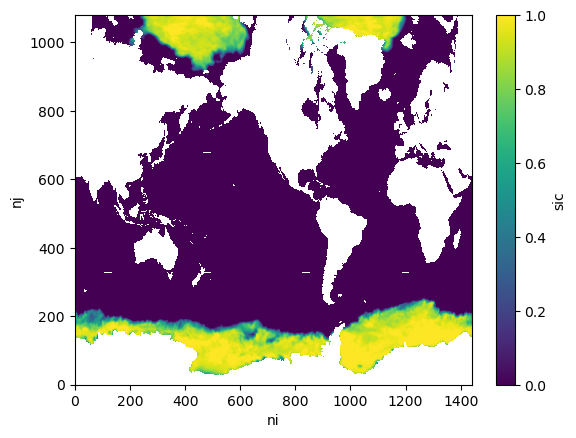

In [29]:
ds.sic.plot()

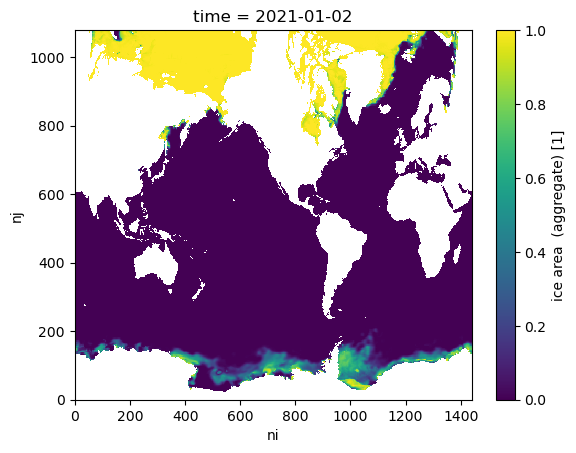

In [30]:
ds_cice.aice_d.isel(time=0).plot()

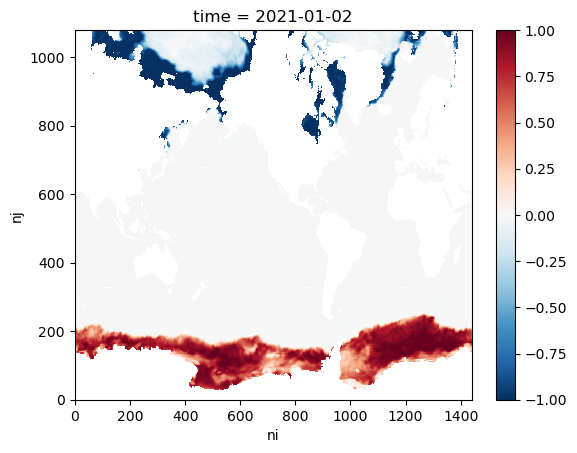

In [31]:
diff = ds.sic-ds_cice.aice_d.isel(time=0)
diff.plot()

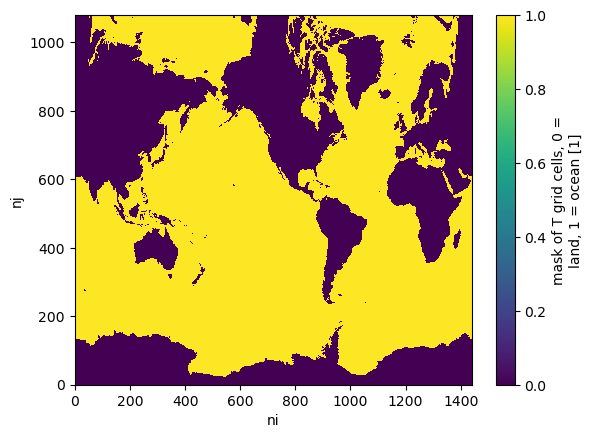

In [32]:
ds_cice.tmask.plot()